In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
festival = pd.read_excel("./dati-festival-sanremo-1951-2023.xlsx", engine="openpyxl")
festival.head()

,Anno,Periodo,Sede,Presentatore,Partecipanti,Vincitore
0,1951,29-31 gennaio,Casinò di Sanremo,Nunzio Filogamo,3,Nilla Pizzi
1,1952,28-30 gennaio,Casinò di Sanremo,Nunzio Filogamo,5,Nilla Pizzi
2,1953,29-31 gennaio,Casinò di Sanremo,Nunzio Filogamo,10,Carla Boni
3,1954,28-30 gennaio,Casinò di Sanremo,Nunzio Filogamo,12,Gino Latilla
4,1955,27-29 gennaio,Casinò di Sanremo,Armando Pizzo,15,Claudio Villa


In [7]:
canzoni = pd.read_excel("./dati-canzoni-spotify-sanremo-1951-2023.xlsx", engine="openpyxl")
canzoni.head()

,Canzone,Artista,Anno_ultimo_rilascio,Durata (min),Popolarità,URL immagine album
0,Lasciami cantare una canzone,Achille Togliani,2012,3.448950,20,https://i.scdn.co/image/ab67616d0000b27305045a...
1,Vecchio scarpone,I Girasoli,2011,3.033250,26,https://i.scdn.co/image/ab67616d0000b273ee46e2...
2,Vecchia villa comunale,Gino Latilla,2015,3.948667,0,https://i.scdn.co/image/ab67616d0000b2734c3955...
3,No Pierrot,Aurelio Fierro,2009,3.661483,0,https://i.scdn.co/image/ab67616d0000b2739f58a2...
4,Il passerotto,Ciansunier,2017,2.712433,3,https://i.scdn.co/image/ab67616d0000b273fe1ca7...


In [11]:
classifica = pd.read_excel("./dati-classifica-sanremo-1951-2023.xlsx", engine="openpyxl")
classifica.head()

,Unnamed: 0,Posizione,Interprete,Canzone,anno,Autori
0,0,1º,Nilla Pizzi,Grazie dei fiori,1951,Gian Carlo Testoni e Mario Panzeri
1,1,2º,Nilla Pizzi e Achille Togliani,La luna si veste d'argento,1951,Biri
2,2,3º,Achille Togliani,Serenata a nessuno,1951,Walter Colì
3,3,F,Achille Togliani e Duo Fasano,Al mercato di Pizzighettone,1951,Aldo Locatelli
4,4,F,Nilla Pizzi e Achille Togliani,Eco tra gli abeti,1951,Enzo Bonagura


In [13]:
classifica = classifica.drop(columns=["Unnamed: 0"])

In [15]:
classifica.head()

,Posizione,Interprete,Canzone,anno,Autori
0,1º,Nilla Pizzi,Grazie dei fiori,1951,Gian Carlo Testoni e Mario Panzeri
1,2º,Nilla Pizzi e Achille Togliani,La luna si veste d'argento,1951,Biri
2,3º,Achille Togliani,Serenata a nessuno,1951,Walter Colì
3,F,Achille Togliani e Duo Fasano,Al mercato di Pizzighettone,1951,Aldo Locatelli
4,F,Nilla Pizzi e Achille Togliani,Eco tra gli abeti,1951,Enzo Bonagura


**I nned to clean Posizione from classifica tab**

In [19]:
classifica.Posizione.value_counts(dropna=False)

Posizione
NF     433
F      106
1º      70
2º      68
3º      66
      ... 
6        1
4°       1
24°      1
23°      1
28º      1
Name: count, Length: 79, dtype: int64

In [21]:
#take care of ° and º
classifica.Posizione = classifica.Posizione.str.replace("°", "", regex="True")
classifica.Posizione = classifica.Posizione.str.replace("º", "", regex="True")
classifica.Posizione = classifica.Posizione.astype(str).str.strip()

In [23]:
classifica.Posizione.value_counts(dropna=False)

Posizione
NF                 433
F                  106
1                   73
2                   72
3                   68
5                   64
4                   63
6                   62
8                   60
7                   60
9                   58
10                  58
12                  45
11                  44
13                  42
14                  41
15                  32
16                  30
17                  25
18                  24
19                  23
2 (pari merito)     22
20                  22
NF (E4)             21
NF (E3)             15
21                  12
22                  12
NF (E2)             11
nan                 10
23                   9
24                   8
25                   5
26                   4
3 (ex aequo)         4
9 (ex aequo)         3
11 (ex aequo)        2
6 (ex aequo)         2
8 (ex aequo)         2
13 (ex aequo)        2
15 (ex aequo)        2
F (9)[24]            1
27                   1
Esclusi              1
E

In [25]:
year_counts = classifica.groupby("anno")["Canzone"].count().to_dict()

In [27]:
def replace_nf(row):
    if "NF" in str(row["Posizione"]):
        return year_counts.get(row["anno"], 0)
    return row["Posizione"]

In [29]:
#replace "NF" with total number of songs in the same year. Non-finalist is replaced with last place
classifica.Posizione = classifica.apply(replace_nf, axis=1)

In [31]:
#take first part of string if there's a space
classifica.Posizione = classifica.Posizione.astype(str).str.split(" ").str[0]

In [33]:
#replace "F" with "10": finalist is replaced with position 10
classifica.Posizione = classifica.Posizione.str.replace("F","10")

In [35]:
#replace "Escluso/a/i" with "" 
classifica.Posizione = classifica.Posizione.apply(lambda x: "0" if "Esclus" in x or "nan" in x else x)

In [37]:
classifica.Posizione = classifica.Posizione.apply(int)

In [39]:
classifica.Posizione.value_counts().sort_index(ascending=True)

Posizione
0      13
1      73
2      94
3      72
4      63
5      64
6      64
7      60
8      62
9      61
10    171
11     46
12     45
13     44
14     49
15     39
16     44
17     25
18     24
19     32
20    120
21     12
22     28
23     15
24     92
25      5
26     28
27      1
28     61
29      9
30    100
32     37
36     10
Name: count, dtype: int64

<Axes: xlabel='Posizione', ylabel='count'>

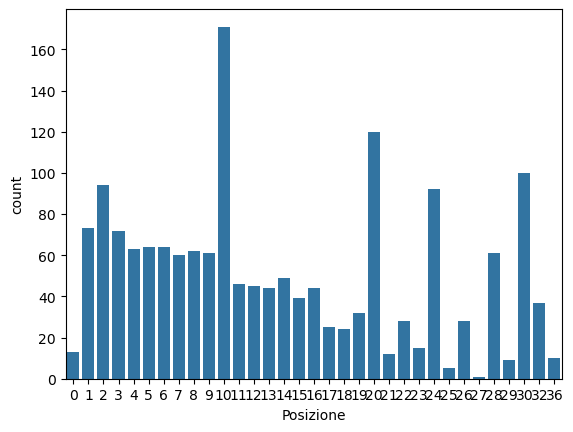

In [41]:
sns.countplot(data=classifica, x="Posizione")

In [44]:
canzoni.Canzone.value_counts()

Canzone
Vorrei                                     3
Sei tu                                     3
Ora                                        3
Lasciami cantare una canzone               2
Voce                                       2
                                          ..
Il telegramma                              1
Sei stata tu                               1
Decidi tu per me                           1
Io credo (Ci son cose più grandi di te)    1
Cause perse                                1
Name: count, Length: 1535, dtype: int64

In [48]:
#I remove duplicates in canzoni tab

In [50]:
canzoni = canzoni.drop_duplicates().reset_index(drop=True)

In [52]:
canzoni.Canzone.value_counts()

Canzone
Lasciami cantare una canzone    1
Papa nero                       1
Fragolina                       1
E penserò al tuo viso...        1
Confusa e felice                1
                               ..
La canta                        1
Fiume grande                    1
Complici                        1
Capelli sciolti                 1
Cause perse                     1
Name: count, Length: 1535, dtype: int64

In [54]:
classifica.Canzone.value_counts()

Canzone
Sei tu                    3
Vorrei                    3
Ora                       3
Dedicato a te             2
Portami via               2
                         ..
Un po' di coraggio        1
In controluce             1
Ah! L'amore               1
Il matto del villaggio    1
Cause perse               1
Name: count, Length: 1629, dtype: int64

In [56]:
#I remove duplicates in classifica tab

In [58]:
classifica = classifica.drop_duplicates().reset_index(drop=True)

In [60]:
classifica.Canzone.value_counts()

Canzone
Sei tu                    3
Vorrei                    3
Ora                       3
Dedicato a te             2
Portami via               2
                         ..
Un po' di coraggio        1
In controluce             1
Ah! L'amore               1
Il matto del villaggio    1
Cause perse               1
Name: count, Length: 1629, dtype: int64

* I removed duplicates in Canzoni
* I tried to remove duplicates in Classifica but there are no duplicates. There are songs with the same name presented in different years. They are different songs. 

In [66]:
#Now I joi classifica tab with canzoni tab

In [68]:
merged = classifica.merge(canzoni, how="left", on="Canzone")

In [70]:
merged

,Posizione,Interprete,Canzone,anno,Autori,Artista,Anno_ultimo_rilascio,Durata (min),Popolarità,URL immagine album
0,1,Nilla Pizzi,Grazie dei fiori,1951,Gian Carlo Testoni e Mario Panzeri,NaN,NaN,NaN,NaN,NaN
1,2,Nilla Pizzi e Achille Togliani,La luna si veste d'argento,1951,Biri,NaN,NaN,NaN,NaN,NaN
2,3,Achille Togliani,Serenata a nessuno,1951,Walter Colì,NaN,NaN,NaN,NaN,NaN
3,10,Achille Togliani e Duo Fasano,Al mercato di Pizzighettone,1951,Aldo Locatelli,NaN,NaN,NaN,NaN,NaN
4,10,Nilla Pizzi e Achille Togliani,Eco tra gli abeti,1951,Enzo Bonagura,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1658,24,Olly,Polvere,2023,"Olly, E. Lovito e J. Boverod",Tedua,2020.0,4.216517,63.0,https://i.scdn.co/image/ab67616d0000b273773f82...
1659,25,Anna Oxa,Sali (canto dell'anima),2023,"A. Oxa, F. Bianconi, Kaballà e F. Zanotti",Anna Oxa,2023.0,4.215183,42.0,https://i.scdn.co/image/ab67616d0000b2739d992d...
1660,26,Will,Stupido,2023,"Will, S. Cremonini e A. Pugliese",Massimo Pericolo,2021.0,3.123850,67.0,https://i.scdn.co/image/ab67616d0000b2734cc0a9...
1661,27,Shari,Egoista,2023,"Shari, M. Pisciottu, L. Fenudi e R. Puddu",Shari,2023.0,2.887967,45.0,https://i.scdn.co/image/ab67616d0000b273edd542...


<Axes: xlabel='Posizione', ylabel='count'>

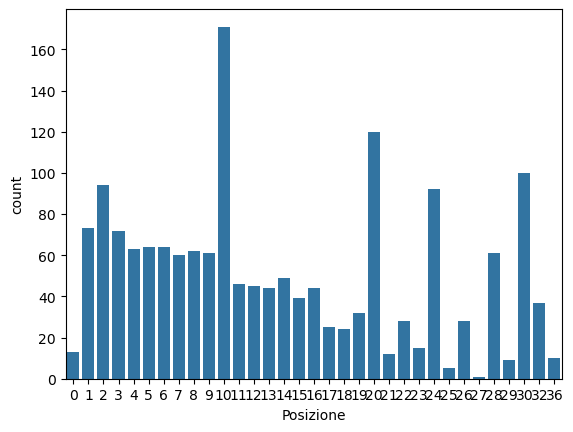

In [72]:
sns.countplot(data=merged, x="Posizione")

<Axes: xlabel='Posizione', ylabel='Count'>

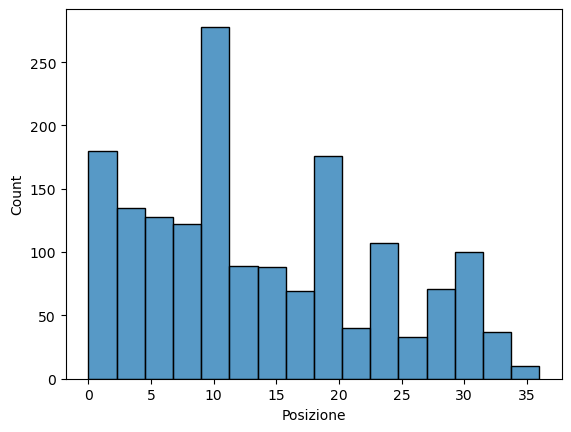

In [74]:
sns.histplot(data=merged, x="Posizione")

<Axes: xlabel='Popolarità', ylabel='Count'>

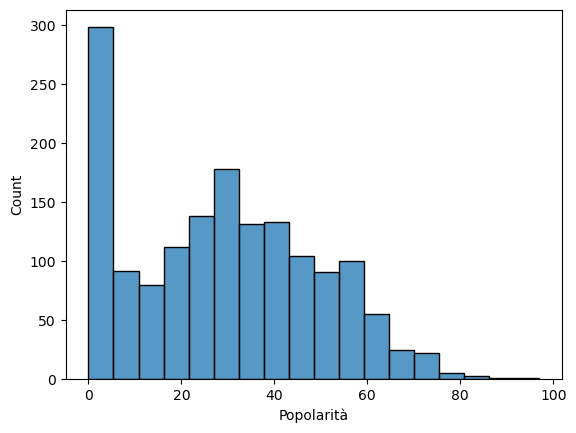

In [76]:
sns.histplot(data=merged, x="Popolarità")

* This is a LEFT JOIN, I keep all data from classifica tab
* If I only wanted the songs listed on Spotify, I would use an INNER JOIN. But I don't want this now. I can just add a filter later on Looker

**I need to clean Interprete**

In [81]:
merged.Interprete.value_counts()

Interprete
Anna Oxa                          14
Toto Cutugno                      12
Michele Zarrillo                  12
Matia Bazar                       12
Nilla Pizzi                       10
                                  ..
Luciano Tajoli - Mal               1
Gianni Nazzaro - Marisa Sannia     1
Fausto Leali - Carmen Villani      1
Tony Renis - Sergio Leonardi       1
Sethu                              1
Name: count, Length: 1064, dtype: int64

In [83]:
#look at first three postions
merged[(merged.Posizione >= 1) & (merged.Posizione <= 3)].groupby("Interprete")["anno"].count().sort_values(ascending=False)

Interprete
Toto Cutugno                                                  6
Nilla Pizzi                                                   4
Al Bano e Romina Power                                        4
Giorgia                                                       3
Marco Mengoni                                                 3
                                                             ..
Gino Latilla - Franco Ricci                                   1
Gino Latilla - Nilla Pizzi                                    1
Gino Latilla - Tonina Torrielli                               1
Gino Latilla e Doppio Quintetto Vocale - Giorgio Consolini    1
Wilma Goich - The New Christy Minstrels                       1
Name: anno, Length: 201, dtype: int64

In [86]:
#I split rows with multiple interpreters in more rows with a single interpreter**

In [88]:
merged_2 = merged.copy()

In [90]:
#split on " - "
merged_2["Interprete"] = merged_2["Interprete"].str.split(' - ')
merged_2 = merged_2.explode('Interprete').reset_index(drop=True)

In [92]:
#some renaming
merged_2["Interprete"] = merged_2["Interprete"].replace("Marcella e Gianni Bella","Marcella Bella e Gianni Bella")

In [94]:
#split on " e " but not for all artists
merged_2["Interprete"] = merged_2["Interprete"].apply(
    lambda x: x if x in ["Ricchi e Poveri","Elio e le Storie Tese","Ely Neri e la sua orchestra"] else x.split(" e ")
)
merged_2 = merged_2.explode("Interprete").reset_index(drop=True)

In [96]:
#split on ", "
merged_2["Interprete"] = merged_2["Interprete"].str.split(', ')
merged_2 = merged_2.explode('Interprete').reset_index(drop=True)

In [98]:
#spit on " & " bur some bands have & in their names
merged_2["Interprete"] = merged_2["Interprete"].apply(
    lambda x: x if x in["Paola & Chiara", "Chad & Jeremy", "Maurizio & Fabrizio", "Mouth & MacNeal", "Carmen & Thompson", "Milk & Coffee"] 
    else x.split(" & ")
)
merged_2 = merged_2.explode('Interprete').reset_index(drop=True)

In [100]:
merged_2["Interprete"] = merged_2["Interprete"].replace("Irama[20]","Irama")

In [102]:
merged_2["Interprete"] = merged_2["Interprete"].replace("Ron (con Tosca non accreditata)","Ron con Tosca")

In [104]:
#split on " con "
merged_2["Interprete"] = merged_2["Interprete"].str.split(' con ')
merged_2 = merged_2.explode('Interprete').reset_index(drop=True)

In [106]:
#split on " feat "
merged_2["Interprete"] = merged_2["Interprete"].str.split(' feat ')
merged_2 = merged_2.explode('Interprete').reset_index(drop=True)

In [108]:
#split on " feat. "
merged_2["Interprete"] = merged_2["Interprete"].str.split(' feat. ')
merged_2 = merged_2.explode('Interprete').reset_index(drop=True)

In [110]:
merged_2 = merged_2.drop_duplicates().reset_index(drop=True)

In [112]:
merged_2

,Posizione,Interprete,Canzone,anno,Autori,Artista,Anno_ultimo_rilascio,Durata (min),Popolarità,URL immagine album
0,1,Nilla Pizzi,Grazie dei fiori,1951,Gian Carlo Testoni e Mario Panzeri,NaN,NaN,NaN,NaN,NaN
1,2,Nilla Pizzi,La luna si veste d'argento,1951,Biri,NaN,NaN,NaN,NaN,NaN
2,2,Achille Togliani,La luna si veste d'argento,1951,Biri,NaN,NaN,NaN,NaN,NaN
3,3,Achille Togliani,Serenata a nessuno,1951,Walter Colì,NaN,NaN,NaN,NaN,NaN
4,10,Achille Togliani,Al mercato di Pizzighettone,1951,Aldo Locatelli,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2247,24,Olly,Polvere,2023,"Olly, E. Lovito e J. Boverod",Tedua,2020.0,4.216517,63.0,https://i.scdn.co/image/ab67616d0000b273773f82...
2248,25,Anna Oxa,Sali (canto dell'anima),2023,"A. Oxa, F. Bianconi, Kaballà e F. Zanotti",Anna Oxa,2023.0,4.215183,42.0,https://i.scdn.co/image/ab67616d0000b2739d992d...
2249,26,Will,Stupido,2023,"Will, S. Cremonini e A. Pugliese",Massimo Pericolo,2021.0,3.123850,67.0,https://i.scdn.co/image/ab67616d0000b2734cc0a9...
2250,27,Shari,Egoista,2023,"Shari, M. Pisciottu, L. Fenudi e R. Puddu",Shari,2023.0,2.887967,45.0,https://i.scdn.co/image/ab67616d0000b273edd542...


**How many times an artist reached the first 3 positions?**

In [120]:
merged_2[(merged_2.Posizione >= 1) & (merged_2.Posizione <= 3)].groupby("Interprete")["anno"].count().sort_values(ascending=False)

Interprete
Nilla Pizzi           8
Domenico Modugno      7
Claudio Villa         7
Toto Cutugno          7
Gino Latilla          7
                     ..
I Giganti             1
I Santo California    1
Irene Grandi          1
Ivana Spagna          1
Yukari Ito            1
Name: anno, Length: 213, dtype: int64

**How many participations per artists?**

In [123]:
merged_2.groupby("Interprete")["anno"].nunique().sort_values(ascending=False)

Interprete
Al Bano                 15
Anna Oxa                15
Milva                   15
Toto Cutugno            13
Claudio Villa           13
                        ..
I Camaleonti             1
I Nostri Figli           1
I Nuovi Angeli           1
I Ragazzi di Scampia     1
le Piccole Donne         1
Name: anno, Length: 931, dtype: int64

**How many songs presented per artist?**

In [126]:
merged_2.groupby("Interprete")["anno"].count().sort_values(ascending=False)

Interprete
Gino Latilla             32
Nilla Pizzi              30
Achille Togliani         29
Duo Fasano               28
Claudio Villa            26
                         ..
Ivan Segreto              1
Jalisse                   1
Jean-François Michael     1
Jenny B                   1
le Piccole Donne          1
Name: anno, Length: 931, dtype: int64

In [128]:
merged_2.groupby("Interprete")["Canzone"].nunique().sort_values(ascending=False)

Interprete
Gino Latilla             32
Nilla Pizzi              30
Achille Togliani         29
Duo Fasano               28
Claudio Villa            26
                         ..
Ivan Segreto              1
Jalisse                   1
Jean-François Michael     1
Jenny B                   1
le Piccole Donne          1
Name: Canzone, Length: 931, dtype: int64

In [130]:
merged_2.groupby("anno")["Interprete"].nunique().sum()

1880

In [132]:
merged_2.groupby("anno")["Interprete"].nunique()

anno
1951     3
1952     5
1953    10
1954    12
1955    15
        ..
2019    27
2020    25
2021    28
2022    29
2023    28
Name: Interprete, Length: 73, dtype: int64

In [134]:
festival.Partecipanti.sum()

2226

* Some discrepancies between the calculation of total participants from calssifica tab vs the value provided in festival tab
* It might depend on the procedure adopted to split and isolate artists from Interprete
* It might also depend on what is considered a participant in fastival tab. It seems to vary across editions

In [137]:
festival.loc[:,["Anno","Partecipanti"]]

,Anno,Partecipanti
0,1951,3
1,1952,5
2,1953,10
3,1954,12
4,1955,15
...,...,...
68,2019,24
69,2020,32
70,2021,34
71,2022,25


In [139]:
merged_2[merged_2.anno==1967]["Interprete"].nunique()

58

In [141]:
festival[festival.Anno==1967]["Partecipanti"]

16    58
Name: Partecipanti, dtype: int64

**Popularity**

<Axes: ylabel='Popolarità'>

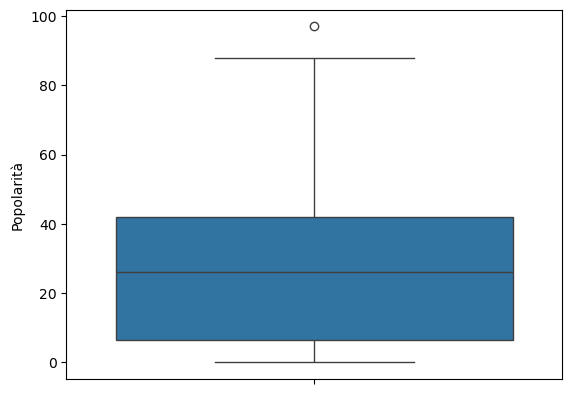

In [145]:
sns.boxplot(data=merged_2, y=merged_2.Popolarità)

In [147]:
merged_2.Popolarità.describe()

count    2127.000000
mean       26.672308
std        20.252157
min         0.000000
25%         6.500000
50%        26.000000
75%        42.000000
max        97.000000
Name: Popolarità, dtype: float64

In [149]:
canzoni.Popolarità.describe()

count    1535.000000
mean       28.530293
std        20.096027
min         0.000000
25%        10.000000
50%        28.000000
75%        43.500000
max        97.000000
Name: Popolarità, dtype: float64

In [151]:
canzoni[canzoni.Popolarità >= 28].loc[:,["Artista","Canzone","Popolarità"]].sort_values(by="Popolarità",ascending=False)

,Artista,Canzone,Popolarità
1024,Feid,Luna,97
1117,Creedence Clearwater Revival,Fortuna,88
602,JAY-Z,New York,86
670,G-Eazy,Tulilemble,84
1204,Tame Impala,Nel perdono,82
...,...,...,...
464,Dori Ghezzi,Tu nella mia vita,28
1123,Little Tony,Non si cresce mai,28
1128,Natale Galletta,Sei la vita mia,28
485,Marnage,Povero,28


In [153]:
merged_2[merged_2.Popolarità >= 28].loc[:,["Interprete","anno","Artista","Anno_ultimo_rilascio","Canzone","Popolarità"]].sort_values(by="Popolarità",ascending=False)

,Interprete,anno,Artista,Anno_ultimo_rilascio,Canzone,Popolarità
1633,Loredana Bertè,1997,Feid,2023.0,Luna,97.0
1740,Luca Barbarossa,2003,Creedence Clearwater Revival,1969.0,Fortuna,88.0
1146,Lorella Pescerelli,1979,JAY-Z,2009.0,New York,86.0
1222,Domenico Mattia,1981,G-Eazy,2014.0,Tulilemble,84.0
1849,Al Bano,2007,Tame Impala,2015.0,Nel perdono,82.0
...,...,...,...,...,...,...
996,Wess,1973,Dori Ghezzi,2000.0,Tu nella mia vita,28.0
997,Dori Ghezzi,1973,Dori Ghezzi,2000.0,Tu nella mia vita,28.0
1018,Junior Magli,1973,Marnage,2022.0,Povero,28.0
1634,Alessandro Mara,1997,Franco Califano,2008.0,Attimi,28.0


In [155]:
merged_2[merged_2.Popolarità >= 28].groupby("Interprete")["Popolarità"].mean().sort_values(ascending=False)

Interprete
Lorella Pescerelli    86.0
Domenico Mattia       84.0
Samuele Bersani       80.0
Irene Fornaciari      79.0
Rocco Hunt            78.0
                      ... 
Enzo Ghinazzi         28.0
Dori Ghezzi           28.0
Polimeno              28.0
Dino                  28.0
i Diesel              28.0
Name: Popolarità, Length: 573, dtype: float64

**I save the dataframes into csv files** 

In [159]:
festival.to_csv("festival.csv", index=None)
canzoni.to_csv("canzoni.csv", index=None)
classifica.to_csv("classifica.csv", index=None)

In [164]:
merged_2.to_csv("merged_left_sing_art.csv", index=None)